# 05 — From leading reactive power to overvoltage: the evidence

**What this notebook is.** The first four notebooks established a measured fact: New Zealand's
distribution networks have drifted to net-**leading** reactive power overnight, driven mostly
by the changing make-up of demand. This notebook closes the loop to the thing that actually
matters — **voltage**. It (1) explains, in plain terms, why leading reactive power at light
load raises voltage; (2) reproduces from public data the part of the "asset response" that we
*can* compute (distribution capacitors being removed); (3) lays out the rest of the verified
evidence that the NZ system is *already responding* to overvoltage pressure (transmission
reactors going in, the regulatory voltage band being widened); (4) connects this to two 2025
overseas blackouts caused by the same regime; and (5) shows the gap in the rules.

**A scope boundary we hold firmly (EA hat).** This notebook states the **technical** picture
only. It does **not** adjudicate who should pay or who is at fault, and it does **not** claim
any specific NZ protection trip was an overvoltage trip — where a near-miss is mentioned, it is
as a *regime* indicator, with the actual trip cause stated accurately. Those distinctions are
load-bearing and are kept throughout.

**Bottom line.** The physics is textbook, the asset response is real and verified from public
records (capacitors coming out at distribution, reactors going in at transmission, the voltage
band widened), and the same regime has already blacked out two systems abroad. The response so
far treats the network-side *symptom*; the demand-side *driver* quantified in notebooks 02–03
remains unnamed and unmanaged in the rules — the "missing defence layer."

In [1]:
import sys
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for _cand in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_cand / "repro.py").exists():
        sys.path.insert(0, str(_cand))
        break
import repro
repro.set_style()
warnings.filterwarnings("ignore")

pdb = pd.read_parquet(repro.CACHE / "edb_parameter_db.parquet")

## 1. Why leading reactive power raises voltage (the physics, plainly)

**The one relationship to hold in your head.** Along any power line there is a small voltage
change between the sending and receiving ends that depends mostly on the *reactive* power
flowing and the line's reactance:

> **ΔV ≈ (R·P + X·Q) / V**, and on the grid the reactance term **X·Q** dominates.

- When reactive power is **lagging** (`Q > 0`, the historical norm — motors and transformers
  drawing it), the voltage **drops** along the line toward the load. Networks were designed
  around this: tap-changers and capacitors were there to *prop voltage up*.
- When reactive power is **leading** (`Q < 0`, the new overnight reality — cables and modern
  electronics injecting it), the sign flips and voltage is **pushed up**.

**Why overnight is the dangerous time.** Two things stack up at 2–5 a.m.: (a) demand is at its
lowest, so there is little load to *absorb* reactive power or to pull voltage back down; and
(b) the leading reactive injection from cables is always on. Low load + leading injection =
the conditions for **overvoltage**. This is exactly the diurnal signature notebook 01 measured:
the problem lives overnight, not at the evening peak.

**Why it can run away (the part that turns a nuisance into a blackout).** As voltage rises,
the leading reactive power from cables rises with the *square* of voltage (Q ∝ V²), pushing
voltage higher still — a positive feedback. If protection then trips a line or transformer for
overvoltage, the remaining network carries more cable per unit of load, so voltage climbs
again, and the next element trips. That cascade is precisely what the two 2025 blackouts below
were found to be.

**Glossary:** *reactance (X)* — the part of a line's opposition to AC that relates to its
magnetic/electric fields (not heating). *Tap-changer* — an adjustable transformer that nudges
voltage up or down. *Per unit (pu)* — voltage expressed as a fraction of nominal (1.0 pu =
nominal; 1.10 pu = 10% high).

## 2. Leg 1 of the asset response — distribution capacitors are coming OUT  [V, computed here]

**Plain bottom line.** If networks were suffering *low* voltage, they would be *adding*
capacitors (which raise voltage). Instead they are **removing** them — the unmistakable sign of
the opposite problem. We can show this directly from the Commerce Commission disclosures we
assembled in notebook 00.

**What to read / what it does NOT say.** This is **counts** of capacitor banks, not their MVAr
ratings, and the series only starts in 2013 with a definitional break around 2014–15 (handled
in notebook 00). So it shows the *direction* — a flat-to-shrinking fleet — not a precise MVAr
figure. The direction is enough for the argument: a static or shrinking capacitor fleet cannot
be *causing* the rising leading trend, and the removals signal networks reacting to high
voltage.

Distribution capacitor banks (Commerce Commission Sch 9a, 'All' networks, post-2015):
  National : 298 (2015)  ->  254 (2025)   — flat-to-declining
  Vector   : 104 (2015)  ->  57 (2025)   — 47 banks removed


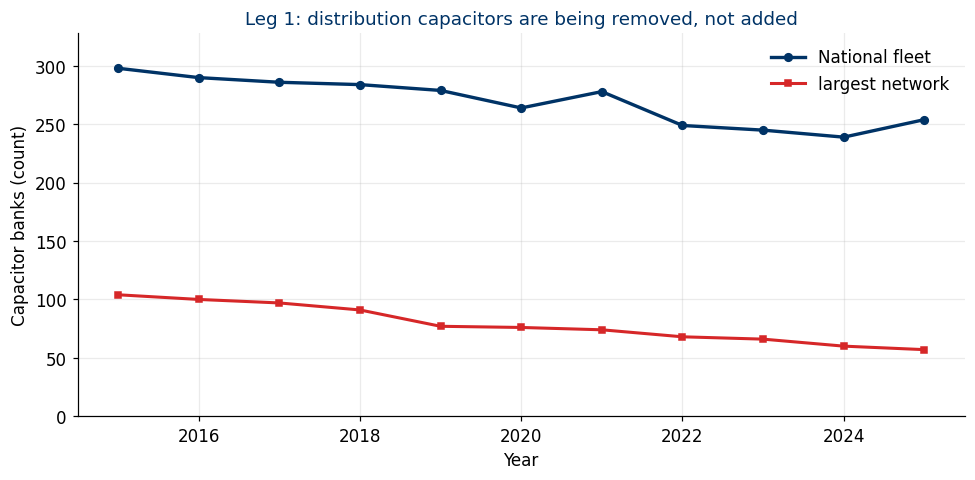

In [2]:
nat_caps = pdb[pdb.year >= 2015].groupby("year").cap_end.sum()
vector = pdb[pdb.edb == "Vector Lines"].set_index("year").cap_end
print("Distribution capacitor banks (Commerce Commission Sch 9a, 'All' networks, post-2015):")
print(f"  National : {int(nat_caps.iloc[0])} ({int(nat_caps.index[0])})  ->  "
      f"{int(nat_caps.iloc[-1])} ({int(nat_caps.index[-1])})   — flat-to-declining")
print(f"  Vector   : {int(vector.loc[2015])} (2015)  ->  {int(vector.loc[2025])} (2025)   "
      f"— {int(vector.loc[2015]-vector.loc[2025])} banks removed")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(nat_caps.index, nat_caps.values, "-o", color=repro.EA_BLUE, lw=2.2, ms=5,
        label="National fleet")
ax.plot(vector.loc[2015:].index, vector.loc[2015:].values, "-s", color=repro.RED, lw=2, ms=4,
        label="largest network")
ax.set_xlabel("Year"); ax.set_ylabel("Capacitor banks (count)")
ax.set_title("Leg 1: distribution capacitors are being removed, not added")
ax.legend(); ax.set_ylim(0, nat_caps.max() * 1.1)
fig.tight_layout(); fig.savefig(repro.FIGURES / "05_capacitors_out.png"); plt.show()

## 3. Legs 2 & 3 of the asset response — verified from external public sources  [V]

These two legs cannot be computed from our dataset; they are documented from primary public
sources and are presented here as **verified external evidence**, with sources, exactly as a
reader would need to check them. (Pending final-use hardening: confirm exact MVAr and
commissioning dates against the Transpower / Commerce Commission PDFs, and the verbatim
regulation wording — flagged below.)

### Leg 2 — Transmission shunt reactors going IN, explicitly to manage overvoltage  [V]

Shunt reactors *absorb* leading reactive power — the deliberate antidote to overvoltage. The
grid operator has been installing them in the Upper North Island, the worst overnight-OV region:

| Asset | Rating | In service | Source |
|---|---|---|---|
| Otahuhu reactor R472 | 50 MVAr | 2022 | NIPS-2 + Transpower System Security Forecast |
| Pakuranga reactors R562, R582 | ~100 MVAr each | 2023 | NIPS-2 + Transpower SSF |
| Wairau Road R182 | ~±50 MVAr | in service | NIPS-1 |
| WUNI programme (Waikato/UNI) shunt reactive | +250 MVAr | RCP3 | Commerce Commission WUNI capex |
| WUNI STATCOMs (Hamilton, Otahuhu) | dynamic | 2020→; Otahuhu 2025 | Transpower / Hitachi Energy |

In the grid operator's **own words** (System Security Forecast / WUNI): *"Prior to these
investments, transmission circuits into the Upper North Island were regularly switched out to
help manage overvoltage conditions … From 2023 the two 100 Mvar reactors at Pakuranga have
dramatically reduced the number of circuit switching operations required to manage high voltages
under N-1 conditions."* That sentence is the overvoltage regime, documented by the party
managing it: routine manual line-switching to hold voltage down overnight, eroding security
margin — which is the mechanism behind NZ's protection near-misses (treated as a *regime*
indicator only; the specific Silverdale trips were Restricted-Earth-Fault maloperations, **not**
overvoltage trips — that distinction is not blurred here).

### Leg 3 — The permitted voltage band was widened  [V]

- **Regulation 28, Electricity (Safety) Regulations 2010**: low-voltage nominal **230 V**,
  historically held within **±6%**, **expanded to ±10% effective 13 November 2025** (Electricity
  (Safety) Amendment Regulations 2025).
- The stated rationale names **solar PV** (raises voltage) and **EV charging** (lowers voltage)
  — it does **not** name the demand-side power-factor composition shift. The band was widened to
  accommodate rising overvoltage pressure while the deeper driver stays unnamed — the same
  blind-spot the paper documents.
- *Sources to quote verbatim before final use:* legislation.govt.nz Reg 28; MBIE discussion
  document and proactive release on the amendment; EEA Voltage Change Guidance.

## 4. The realised risk — two 2025 blackouts from the same regime  [V]

This is not a hypothetical. In 2025 two power systems suffered major blackouts whose official
investigations found the same leading-reactive / overvoltage mechanism at their core:

- **Iberian Peninsula, 28 April 2025** (ENTSO-E Final Report, 20 March 2026). Root cause: *"non-
  effectiveness of voltage control"*; the report states *"the excess of capacitive reactive
  power is the key point"* and **explicitly exonerates inertia**. The cascade was a
  voltage/reactive collapse, not a frequency or inertia event.
- **North Macedonia, 18 May 2025** (ENTSO-E Final Report, 20 April 2026). Root cause: *"a
  sequence of transformer trips triggered by sustained overvoltage"*, driven by light-load
  *"high capacitive reactive power generation of transmission and distribution networks"* — with
  **zero renewables and zero compensation** involved, proving the overvoltage cascade needs no
  solar or DER. The highest voltages occurred **02:00–08:00** — overnight, exactly NZ's window.

**What these do and do not establish.** They establish that the leading-reactive/overvoltage
regime is a *realised* blackout mechanism, not a theoretical worry, and that it operates
overnight at light load. They are corroboration of the *mechanism*; NZ's distinctive
contribution is the 29-year *measurement and decomposition* of how a system drifts into that
regime in the first place (notebooks 01–03). A careful caveat the paper keeps: each event also
had its own local specifics (e.g. Iberia's trigger was fixed-power-factor *generation*, not
load), so we lead with the shared *pattern*, not a one-to-one transfer.

## 5. The gap in the rules — the "missing defence layer"  [V, Code text verified]

New Zealand's reactive-power rules were written for the *old* problem (lagging load pulling
voltage down at the daytime peak), and are silent on the *new* one:

- **Connection Code clause 4.4** sets a minimum power factor of *"not less than 0.95 lagging"*
  — but **only during regional peak demand periods**. There is **no leading limit** and **no
  off-peak / overnight obligation** at all. The one window where overvoltage now lives is the
  one window the rule does not cover.
- **Clause 8.67(4)** measures reactive demand only on weekdays 07:00–21:00 — daytime — and is
  effectively a dead letter (no transmission voltage-support contracts exist under it).
- Of the 29 lines companies, the 11 that charge for power factor all charge **lagging-only**.

**The honest framing (and the framing this paper uses).** The Code did **not cause** the leading
surplus — notebooks 02–03 show the driver is the product-standard demand fleet, which is outside
the Code's reach, and notebook 00 shows the capacitor fleet is shrinking, not the legacy of an
over-correcting rule. What the Code does is **fail to price, limit, monitor, or manage** the
leading reactive power that is now accumulating overnight. The reform value is **building the
missing management/defence layer** (bidirectional and off-peak signals, leading limits,
overvoltage-protection coordination, monitoring) — **not** removing a Code-created cause. We
never write "a fixable Code"; that would imply a cause-removal the evidence forbids.

## Synthesis — the asset response brackets the diagnosis

Put the pieces together and they point one way:

- **Physics:** leading reactive power at light load raises voltage, with a runaway feedback.
- **The network is already responding from both ends:** distribution capacitors coming **out**
  (Leg 1, computed here from public data), transmission reactors going **in** (Leg 2), and the
  permitted voltage band **widened** (Leg 3) — an asset and regulatory response that *brackets*
  the overvoltage problem.
- **The realised risk is documented abroad:** two 2025 blackouts from the same overnight
  leading-reactive regime.
- **The driver is demand-side and unmanaged:** the organic composition shift (notebooks 02–03)
  is what tips networks into the regime, and nothing in the rules names, prices, or manages it.

The system is treating the **symptom** (network-side reactive) while the **driver** (demand-side
composition) stays unnamed and unpriced. That gap — not a Code-created cause — is the paper's
contribution and the reform target. **Hedge in writing, assert in person; descriptive, not
advocacy.**